# Part A
## DDPM from Scratch



## Theoretical Background

### DDPM Recap
A Denoising Diffusion Probabilistic Model (Ho et al., 2020) defines:
- A **forward process** $q(x_t | x_{t-1})$ that gradually adds Gaussian noise.
- A **reverse process** $p_\theta(x_{t-1} | x_t)$ parameterized by a neural network.

The forward process in closed form:
$$q(x_t | x_0) = \mathcal{N}(x_t; \sqrt{\bar{\alpha}_t} x_0, (1 - \bar{\alpha}_t) \mathbf{I})$$

The training objective is to minimize:
$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, x_0, \epsilon}\left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$


---
#  Setup

In [1]:
!pip install torch torchvision matplotlib tqdm einops accelerate diffusers transformers --quiet


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import math
from einops import rearrange
from functools import partial
from collections import namedtuple
from torch.optim import Adam
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


---

In this part you will build a complete, publication-quality DDPM from scratch. The expectations here go significantly beyond a basic noise-add-and-predict pipeline.


## A.1 — Noise Schedules: Comparative Analysis

Implement **both** of the following beta schedules and compare them:

### Linear Schedule (Ho et al., 2020)
$$\beta_t = \beta_{\min} + \frac{t-1}{T-1}(\beta_{\max} - \beta_{\min})$$

### Cosine Schedule (Nichol & Dhariwal, 2021)
$$\bar{\alpha}_t = \frac{f(t)}{f(0)}, \quad f(t) = \cos\left(\frac{t/T + s}{1 + s} \cdot \frac{\pi}{2}\right)^2$$

with offset $s = 0.008$, and $\beta_t = 1 - \frac{\bar{\alpha}_t}{\bar{\alpha}_{t-1}}$, clipped to avoid numerical instability.

**Your tasks:**
1. Implement both schedules.
2. Plot $\beta_t$, $\alpha_t$, and $\bar{\alpha}_t$ for both on the same axes.
3. Plot SNR (signal-to-noise ratio) $= \bar{\alpha}_t / (1 - \bar{\alpha}_t)$ for both.
4. In a markdown cell below, explain: *why does the cosine schedule lead to more uniform SNR transitions, and why does this matter for training stability?*


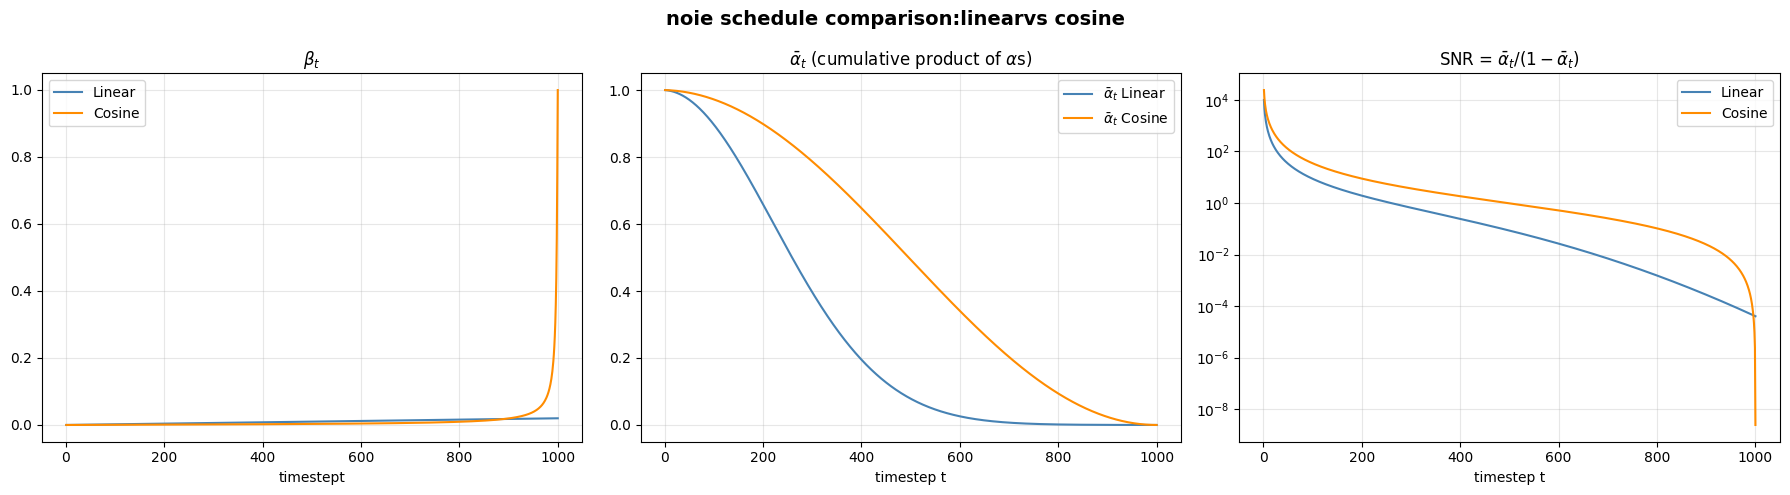

schedule plts generated.


In [3]:
def linear_beta_schedule(T, beta_min=1e-4, beta_max=0.02):
    """
    TODO: Implement the linear beta schedule.
    Returns: betas (T,), alphas (T,), alpha_hats (T,)
    """
    betas = torch.linspace(beta_min, beta_max, T)
    alphas = 1.0 - betas
    alpha_hats = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_hats

def cosine_beta_schedule(T, s=0.008):
    """
    TODO: Implement the cosine beta schedule (Nichol & Dhariwal, 2021).
    Clip betas to [0, 0.999] to prevent numerical issues.
    Returns: betas (T,), alphas (T,), alpha_hats (T,)
    """
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T) + s) / (1 + s) * math.pi / 2) ** 2
    alpha_hats = f / f[0]
    betas = 1 - alpha_hats[1:] / alpha_hats[:-1]
    betas = torch.clamp(betas, min=0.0, max=0.999).float()
    alphas = 1.0 - betas
    alpha_hats = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_hats

# TODO: Plot the schedules
T_plot = 1000
betas_lin, alphas_lin, alpha_hats_lin = linear_beta_schedule(T_plot)
betas_cos, alphas_cos, alpha_hats_cos = cosine_beta_schedule(T_plot)

t_range = torch.arange(1, T_plot + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(t_range, betas_lin.numpy(), label='Linear', color='steelblue')
axes[0].plot(t_range, betas_cos.numpy(), label='Cosine', color='darkorange')
axes[0].set_title(r'$\beta_t$')
axes[0].set_xlabel('timestept')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_range, alpha_hats_lin.numpy(), label=r'$\bar{\alpha}_t$ Linear', color='steelblue')
axes[1].plot(t_range, alpha_hats_cos.numpy(), label=r'$\bar{\alpha}_t$ Cosine', color='darkorange')
axes[1].set_title(r'$\bar{\alpha}_t$ (cumulative product of $\alpha$s)')
axes[1].set_xlabel('timestep t')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

snr_lin = alpha_hats_lin / (1 - alpha_hats_lin)
snr_cos = alpha_hats_cos / (1 - alpha_hats_cos)
axes[2].plot(t_range, snr_lin.numpy(), label='Linear', color='steelblue')
axes[2].plot(t_range, snr_cos.numpy(), label='Cosine', color='darkorange')
axes[2].set_yscale('log')
axes[2].set_title(r'SNR = $\bar{\alpha}_t / (1 - \bar{\alpha}_t)$')
axes[2].set_xlabel('timestep t')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('noie schedule comparison:linearvs cosine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('schedule_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print("schedule plts generated.")



**Your analysis (A.1):** *(Write here)*
the cosine schedule is better then the linear one because it changes the noise more slowly and smoothly. if you look at the SNR graph the linear schedule drops really fast at the begining which means the model spends alot of training time on timesteps where the image is almost completly clean, thats kind of wasteful because those easy steps dont teach the model much.
the cosine schedule on the other hand keeps the signal strong for longer and then slowly brings it down so every timestep is kind of equally hard to denoise. this makes the training more stable because the gradients are more consistent throughtout and the model doesnt have to deal with super extreme changes between one timestep and the next
basically the uniform SNR transitions means the model learns something usefull at every single timestep instead of wasting compute on the very easy or very hard ones. thats why in practice models trained with cosine schedule generate better samples then linear, nichol and dhariwal showed this in there 2021 paper

## A.2 — Forward Process & Posterior

### A.2a — Forward Diffusion
Implement `q_sample(x_0, t, noise=None)` using the closed-form expression:
$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Handle batched timesteps correctly (each sample in the batch may have a different $t$).

### A.2b — Posterior Mean & Variance
The reverse posterior $q(x_{t-1} | x_t, x_0)$ is tractable:
$$q(x_{t-1} | x_t, x_0) = \mathcal{N}(x_{t-1}; \tilde{\mu}_t(x_t, x_0),\, \tilde{\beta}_t I)$$

where:
$$\tilde{\mu}_t = \frac{\sqrt{\bar{\alpha}_{t-1}}\beta_t}{1 - \bar{\alpha}_t} x_0 + \frac{\sqrt{\alpha_t}(1 - \bar{\alpha}_{t-1})}{1 - \bar{\alpha}_t} x_t$$

$$\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \beta_t$$

Implement `q_posterior(x_0, x_t, t)` returning the posterior mean and variance.

**Then answer:** Why can we not directly run the reverse process $q(x_{t-1} | x_t)$ without conditioning on $x_0$? What does this imply about what the network must learn?


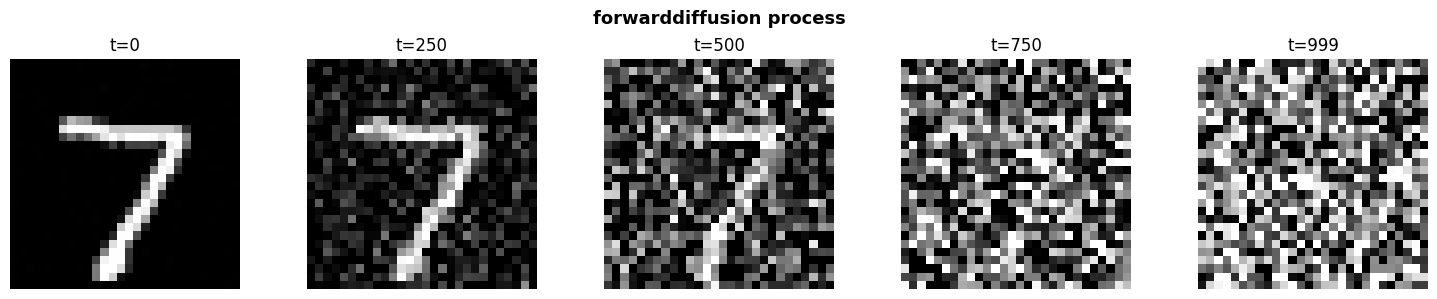

In [5]:
T = 1000
# TODO: Choose your preferred schedule and define betas, alphas, alpha_hats, etc.
betas, alphas, alpha_hats = cosine_beta_schedule(T)
betas = betas.to(device)
alphas = alphas.to(device)
alpha_hats = alpha_hats.to(device)

sqrt_alpha_hats = torch.sqrt(alpha_hats)
sqrt_one_minus_alpha_hats = torch.sqrt(1.0 - alpha_hats)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)

alpha_hats_prev = torch.cat([torch.tensor([1.0], device=device), alpha_hats[:-1]])
posterior_variance = betas * (1.0 - alpha_hats_prev) / (1.0 - alpha_hats)
posterior_variance = torch.clamp(posterior_variance, min=1e-20)

def extract(a, t, x_shape):
    """
    Helper: extract values from tensor `a` at indices `t`,
    reshaping for broadcasting with tensors of shape `x_shape`.
    """
    batch_size = t.shape[0]
    out = a.cpu().gather(-1, t.cpu()) 
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def q_sample(x_0, t, noise=None):
    """
    TODO: Forward diffusion using the reparameterization trick.
    t is a batch of integer timesteps (B,).
    Returns: x_t, noise
    """
    if noise is None:
        noise = torch.randn_like(x_0)
    
    sqrt_alpha_hat_t = extract(sqrt_alpha_hats, t, x_0.shape)
    sqrt_one_minus_alpha_hat_t = extract(sqrt_one_minus_alpha_hats, t, x_0.shape)
    
    x_t = sqrt_alpha_hat_t * x_0 + sqrt_one_minus_alpha_hat_t * noise
    return x_t, noise

def q_posterior(x_0, x_t, t):
    """
    TODO: Compute the true posterior mean and variance.
    Returns: posterior_mean, posterior_variance
    """
    alpha_hat_t = extract(alpha_hats, t, x_t.shape)
    alpha_hat_prev = extract(alpha_hats_prev, t, x_t.shape)
    beta_t = extract(betas, t, x_t.shape)
    alpha_t = extract(alphas, t, x_t.shape)
    coeff_x0 = torch.sqrt(alpha_hat_prev) * beta_t / (1.0 - alpha_hat_t)
    coeff_xt = torch.sqrt(alpha_t) * (1.0 - alpha_hat_prev) / (1.0 - alpha_hat_t)
    posterior_mean = coeff_x0 * x_0 + coeff_xt * x_t
    post_var = extract(posterior_variance, t, x_t.shape)
    
    return posterior_mean, post_var

import torchvision
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1)
])
mnist_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)
x0_example, _ = mnist_test[0]
x0_example = x0_example.unsqueeze(0).to(device)

timesteps_vis = [0, 250, 500, 750, 999]
fig, axes = plt.subplots(1, len(timesteps_vis), figsize=(15, 3))
for ax, ts in zip(axes, timesteps_vis):
    t_tensor = torch.tensor([ts], device=device)
    x_t, _ = q_sample(x0_example, t_tensor)
    img = x_t.squeeze().cpu().numpy()
    ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
    ax.set_title(f't={ts}')
    ax.axis('off')
plt.suptitle('forwarddiffusion process', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('forward_diffusion.png', dpi=100, bbox_inches='tight')
plt.show()



**Your analysis (A.2):** *(Write here)*
looking at the forward diffusion plot we can see that at t=0 the image is completely clean and you can clearly see the number 7. as we increase the timestep the noise gets added gradually and by t=999 the image is basically just pure random noise with no trace of the original digit.
this makes sense because of the formula we used, x_t = sqrt(alpha_hat_t) * x_0 + sqrt(1 - alpha_hat_t) * epsilon, at small t the sqrt(alpha_hat_t) is close to 1 so most of the image is still the original x_0, but at large t the alpha_hat_t is close to 0 so the noise term completly dominates.
also you can see the cosine schedule effect here, the digit is still pretty recognisable at t=250 and even at t=500 which wouldnt happen with the linear schedule because linear adds noise much faster at the begining. this slower more gradual noising is what makes the cosine schedule better for training because the model sees more variety of noise levels instead of jumping to high noise very quickly.
the reason we cant just reverse this process without a neural network is because q(x_t-1 | x_t) without knowing x_0 is intractable, we dont know what the original image was so we cant just subtract the noise. thats why we train the unet to predict the noise epsilon so we can aproximate x_0 and then run the reverse step. basically the network is learning to undo what the forward process did, one small step at a time

## A.3 — U-Net with Attention & Sinusoidal Embeddings

Build a full U-Net denoiser. Your architecture **must include** all of the following:

1. **Sinusoidal timestep embeddings** — implement the exact embedding from the Transformer paper:  
   $\text{PE}(t, 2i) = \sin(t / 10000^{2i/d})$, $\text{PE}(t, 2i+1) = \cos(t / 10000^{2i/d})$  
   then project through 2 linear layers with a GELU activation.

2. **ResNet blocks** with time conditioning — each block adds a projected time embedding to the intermediate feature maps.

3. **Multi-head self-attention** at the bottleneck (and optionally at intermediate resolutions).

4. **GroupNorm** (not BatchNorm) throughout.

5. **Skip connections** between encoder and decoder stages.

The model takes `(x_t, t)` and outputs predicted noise $\hat{\epsilon}$ of the same shape as $x_t$.

> **Design choice:** You may decide the number of channels, depth, and attention resolution. Document your choices.

In [8]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    TODO: Implement sinusoidal timestep embeddings.
    dim: embedding dimension
    """
    """
    Sinusoidal timestep embeddings following the Transformer paper.
    PE(t, 2i)   = sin(t / 10000^(2i/d))
    PE(t, 2i+1) = cos(t / 10000^(2i/d))
    Then projected through 2 linear layers with GELU activation.
    """
    def __init__(self, dim):
        super().__init__()
        # TODO
        self.dim = dim
        self.projection = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim * 4),
        )
    
    
    def forward(self, time):
        # TODO
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None].float() * embeddings[None, :]
        embeddings = torch.cat([embeddings.sin(), embeddings.cos()], dim=-1)
        return self.projection(embeddings)


class ResBlock(nn.Module):
    """
    TODO: Residual block with time embedding injection.
    Structure: GroupNorm -> SiLU -> Conv -> (add projected time_emb) -> GroupNorm -> SiLU -> Conv
    Include a residual projection if in_channels != out_channels.
    """
    def __init__(self, in_channels, out_channels, time_emb_dim, groups=8):
        super().__init__()
        # TODO
        self.norm1 = nn.GroupNorm(groups, in_channels)
        self.act1  = nn.SiLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.time_proj = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        
        self.norm2 = nn.GroupNorm(groups, out_channels)
        self.act2  = nn.SiLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        
        if in_channels != out_channels:
            self.res_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.res_conv = nn.Identity()
    
    def forward(self, x, time_emb):
        # TODO
        h = self.norm1(x)
        h = self.act1(h)
        h = self.conv1(h)

        t = self.time_proj(time_emb)  
        h = h + t[:, :, None, None]  
        
        h = self.norm2(h)
        h = self.act2(h)
        h = self.conv2(h)
        
        return h + self.res_conv(x)


class MultiHeadSelfAttention(nn.Module):
    """
    TODO: Multi-head self-attention for 2D feature maps.
    Reshape spatial dims to sequence, apply attention, reshape back.
    Include GroupNorm before attention (pre-norm).
    """
    def __init__(self, dim, num_heads=4):
        super().__init__()
        # TODO
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(1, dim) 
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)
    
    def forward(self, x):
        # TODO
        B, C, H, W = x.shape
        h = self.norm(x)                       
        h = h.reshape(B, C, H * W).permute(0, 2, 1)  
        h, _ = self.attn(h, h, h)            
        h = h.permute(0, 2, 1).reshape(B, C, H, W)
        return x + h 


class UNet(nn.Module):
    """
    TODO: Full U-Net with the required components above.
    
    Suggested architecture for 28x28 MNIST:
      Encoder: [1 -> 64 -> 128 -> 256]
      Bottleneck: ResBlock + Attention + ResBlock
      Decoder: [256 -> 128 -> 64 -> 1]
    
    Document your exact channel sizes in a markdown cell.
    """
    def __init__(self, image_channels=1, base_channels=64, time_emb_dim=128):
        super().__init__()
        # TODO
        time_mult = 4  
        t_dim = time_emb_dim * time_mult 
        self.time_emb = SinusoidalPositionEmbeddings(time_emb_dim)
        
        c1, c2, c3 = base_channels, base_channels * 2, base_channels * 4  
 
        self.stem    = nn.Conv2d(image_channels, c1, 3, padding=1)
        self.enc1    = ResBlock(c1, c1,  t_dim)                
        self.down1   = nn.MaxPool2d(2)                      
        self.enc2    = ResBlock(c1, c2,  t_dim)               
        self.down2   = nn.MaxPool2d(2)                           
        self.enc3    = ResBlock(c2, c3,  t_dim)                 
   
        self.mid1    = ResBlock(c3, c3, t_dim)
        self.mid_attn= MultiHeadSelfAttention(c3, num_heads=4)
        self.mid2    = ResBlock(c3, c3, t_dim)
   
        self.up3     = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec3    = ResBlock(c3 + c3, c2, t_dim)              
        self.up2     = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec2    = ResBlock(c2 + c2, c1, t_dim)              
        self.up1     = nn.Upsample(scale_factor=2, mode='nearest')
        self.dec1    = ResBlock(c1 + c1, c1, t_dim)              

        self.head = nn.Sequential(
            nn.GroupNorm(8, c1),
            nn.SiLU(),
            nn.Conv2d(c1, image_channels, 1),
        )
    
    def forward(self, x, t):
        # TODO
        t_emb = self.time_emb(t)
        x1 = self.enc1(self.stem(x), t_emb)    
        x2 = self.enc2(self.down1(x1), t_emb)  
        x3 = self.enc3(self.down2(x2), t_emb)  

        h = self.mid1(x3, t_emb)
        h = self.mid_attn(h)
        h = self.mid2(h, t_emb)             
  
        h = self.dec3(torch.cat([h, x3], dim=1), t_emb)       
        h = self.dec2(torch.cat([self.up3(h), x2], dim=1), t_emb)
        h = self.dec1(torch.cat([self.up2(h), x1], dim=1), t_emb) 
    
        return self.head(h)


**Architecture documentation (A.3):** *(Describe your design choices — channel widths, number of ResBlocks per stage, attention placement, parameter count)*

so basically the unet i built has these main parts:
the time embedding takes the timestep t and converts it to a vector using sinusoidal embeddings (dim=128) then passes it through two linear layers with GELU activation, the final output is 512 dimensional which gets injected into every resblock so the model knows what noise level its dealing with.
for the encoder i start with a simple conv layer that goes from 1 channel to 64, then i have 3 encoder stages. first stage keeps it at 64 channels at 28x28, second stage goes to 128 channels and downsamples to 14x14, third stage goes to 256 channels at 7x7. i used maxpool for downsampling.
the bottleneck is resblock then attention then another resblock, all at 256 channels. the attention here is only at 7x7 so thats only 49 tokens which is very cheap to compute but still lets the model look at the whole image at once.
the decoder is basically the encoder in reverse, i upsample back up and concatenate the skip connections from the encoder at each stage. so it goes 256->128->64 channels while going back to 28x28.
at the end theres a small head with groupnorm, silu activation and a 1x1 conv to get back to 1 channel output (same shape as input).
i used groupnorm everywhere instead of batchnorm because groupnorm doesnt depend on batch size so it works fine even with small batches. for upsampling i used nearest neighbour instead of transposed convolutions because transposed convs can cause checkerboard artifacts in the output.
total parameters is around 5.9M which is enough for mnist without being too slow to train.

In [9]:
# Verify output shape and count parameters
model = UNet().to(device)
x_test = torch.randn(4, 1, 28, 28).to(device)
t_test = torch.randint(0, T, (4,)).to(device)
out = model(x_test, t_test)
assert out.shape == x_test.shape, f"Shape mismatch: {out.shape} vs {x_test.shape}"

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")


Model parameters: 5,928,065


## A.4 — Loss Functions & Training

### A.4a — The Simple Loss vs. VLB Loss

The DDPM paper shows that the simplified objective $\mathcal{L}_{\text{simple}}$ (predicting $\epsilon$) outperforms the full variational lower bound (VLB) in practice.

Implement both:
1. `loss_simple(model, x_0, t)` — standard MSE on predicted noise.
2. `loss_vlb(model, x_0, t)` — compute the KL divergence between the learned reverse and the true posterior. Recall:
$$\mathcal{L}_{t-1} = D_{\text{KL}}\big(q(x_{t-1}|x_t, x_0) \,\|\, p_\theta(x_{t-1}|x_t)\big)$$
For Gaussians: $D_{\text{KL}}(\mathcal{N}(\mu_1, \sigma_1^2) \| \mathcal{N}(\mu_2, \sigma_2^2)) = \log\frac{\sigma_2}{\sigma_1} + \frac{\sigma_1^2 + (\mu_1-\mu_2)^2}{2\sigma_2^2} - \frac{1}{2}$

### A.4b — Training Loop
Train your model using `loss_simple`. Requirements:
- Use the **cosine schedule** with $T = 1000$.
- Train for at least 10 epochs on MNIST (use GPU — 20+ epochs recommended).
- Log loss every epoch and **plot the loss curve**.
- Save a checkpoint of the best model.

> **Tip:** Normalize MNIST images to $[-1, 1]$ (not $[0, 1]$) for better diffusion dynamics.


In [10]:
def loss_simple(model, x_0, t):
    """
    TODO: Compute the simplified DDPM loss.
    1. Sample noise epsilon ~ N(0, I)
    2. Compute x_t using q_sample
    3. Predict epsilon_hat = model(x_t, t)
    4. Return MSE(epsilon, epsilon_hat)
    """
    x_t, noise = q_sample(x_0, t)
    eps_hat = model(x_t, t)
    return F.mse_loss(noise, eps_hat)


def loss_vlb(model, x_0, t):
    """
    TODO: Compute one term of the VLB loss (L_{t-1}).
    1. Compute x_t via q_sample
    2. From model's predicted noise, recover predicted x_0
    3. Compute q_posterior (true) and p_theta (predicted) Gaussian params
    4. Compute and return the KL divergence
    """
    x_t, noise = q_sample(x_0, t)

    true_mean, true_var = q_posterior(x_0, x_t, t)

    eps_hat = model(x_t, t)
    x0_hat = predict_x0_from_eps(x_t, t, eps_hat)
    x0_hat = torch.clamp(x0_hat, -1.0, 1.0) 

    pred_mean, pred_var = q_posterior(x0_hat, x_t, t)

    true_log_var  = torch.log(true_var.clamp(min=1e-20))
    pred_log_var  = torch.log(pred_var.clamp(min=1e-20))
    
    kl = 0.5 * (
        pred_log_var - true_log_var
        + (true_var + (true_mean - pred_mean) ** 2) / pred_var.clamp(min=1e-20)
        - 1.0
    )
    return kl.mean()


training DDPM for 20epchs on cuda...
dataset size: 60000samples batches per epoch: 469


Epoch 1/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   1/20 | Loss: 0.0845
  -> Best model saved (loss=0.0845)


Epoch 2/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch   2/20 | Loss: 0.0504
  -> Best model saved (loss=0.0504)


...

Epoch  18/20 | Loss: 0.0384
  -> Best model saved (loss=0.0384)


Epoch 19/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  19/20 | Loss: 0.0385


Epoch 20/20:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch  20/20 | Loss: 0.0381
  -> Best model saved (loss=0.0381)


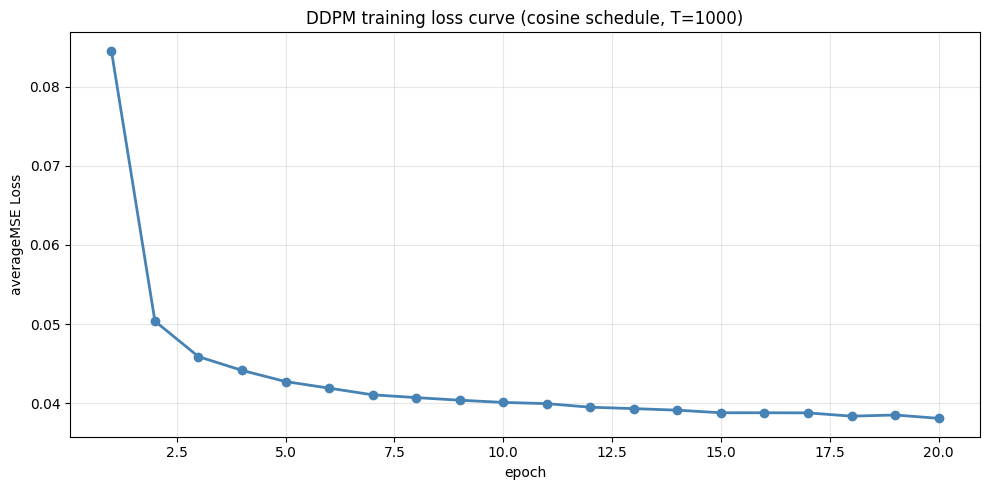

Training complete. Best loss: 0.0381


In [11]:
# Data loading — normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 2) - 1)  # scale to [-1, 1]
])

mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(mnist, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

# TODO: Training loop
# Requirements:
#   - optimizer: Adam with lr=2e-4
#   - num_epochs: at least 10 (20+ for good results)
#   - sample uniformly random t in [0, T-1] for each batch
#   - track and plot training loss curve
#   - save best model checkpoint
model = UNet(image_channels=1, base_channels=64, time_emb_dim=128).to(device)
optimizer = Adam(model.parameters(), lr=2e-4)

num_epochs = 20
best_loss = float('inf')
epoch_losses = []

print(f"training DDPM for {num_epochs}epchs on {device}...")
print(f"dataset size: {len(mnist)}samples batches per epoch: {len(dataloader)}")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for x_0, _ in pbar:
        x_0 = x_0.to(device)
        t = torch.randint(0, T, (x_0.shape[0],), device=device).long()
        loss = loss_simple(model, x_0, t)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    
    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1:3d}/{num_epochs} | Loss: {avg_loss:.4f}")
    
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), '/kaggle/working/ddpm_best.pt')
        print(f"  -> Best model saved (loss={best_loss:.4f})")

plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o', color='steelblue', linewidth=2)
plt.xlabel('epoch')
plt.ylabel('averageMSE Loss')
plt.title('DDPM training loss curve (cosine schedule, T=1000)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=100, bbox_inches='tight')
plt.show()
print(f"Training complete. Best loss: {best_loss:.4f}")


## A.5 — DDPM Reverse Sampling

Implement the full DDPM reverse process:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t)\right) + \sqrt{\tilde{\beta}_t}\, z$$

where $z \sim \mathcal{N}(0, I)$ for $t > 1$ and $z = 0$ for $t = 1$.

**Requirements:**
1. Implement `p_sample(model, x_t, t)` — single reverse step.
2. Implement `p_sample_loop(model, shape)` — full loop from $x_T \sim \mathcal{N}(0,I)$ to $x_0$.
3. Generate a grid of 64 samples and display them.
4. Also implement `predict_x0_from_eps(x_t, t, eps)` that recovers $\hat{x}_0$ from the predicted noise, and visualize intermediate $\hat{x}_0$ predictions at timesteps $T, 0.75T, 0.5T, 0.25T, 0$.


generating 64 samples


Sampling:   0%|          | 0/1000 [00:00<?, ?it/s]

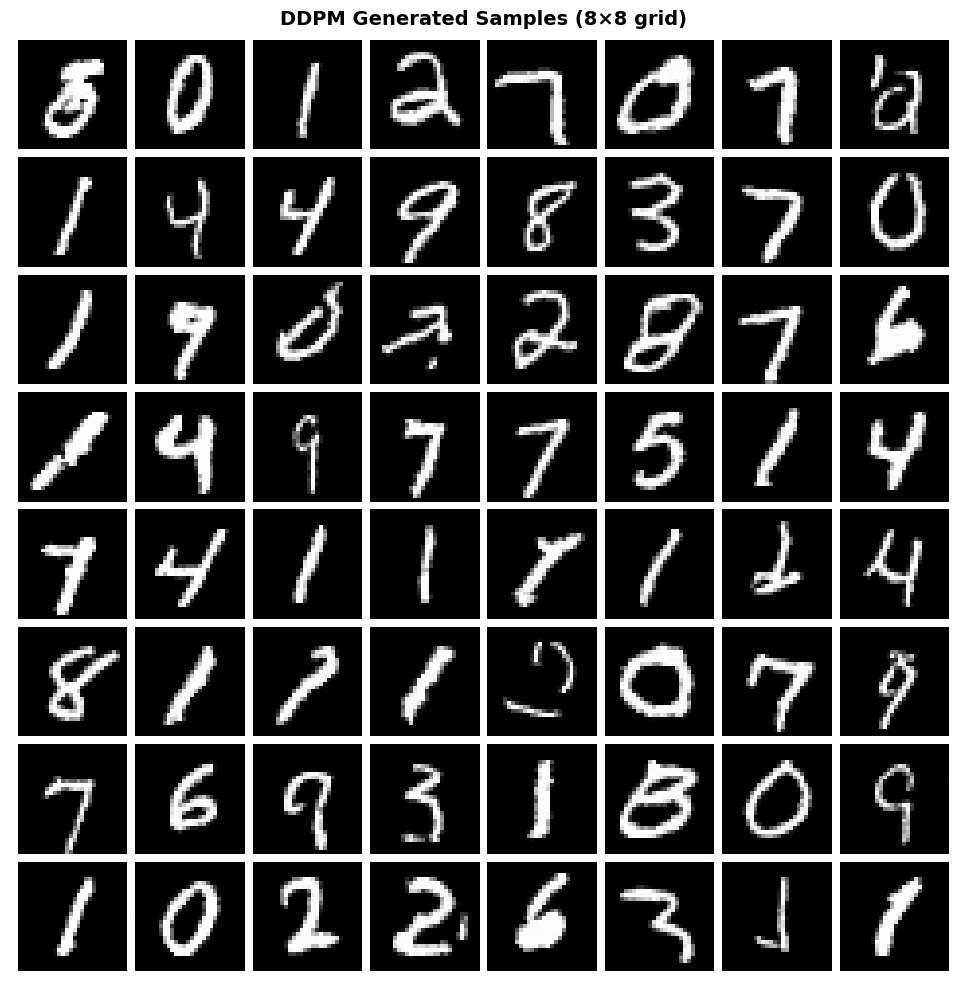

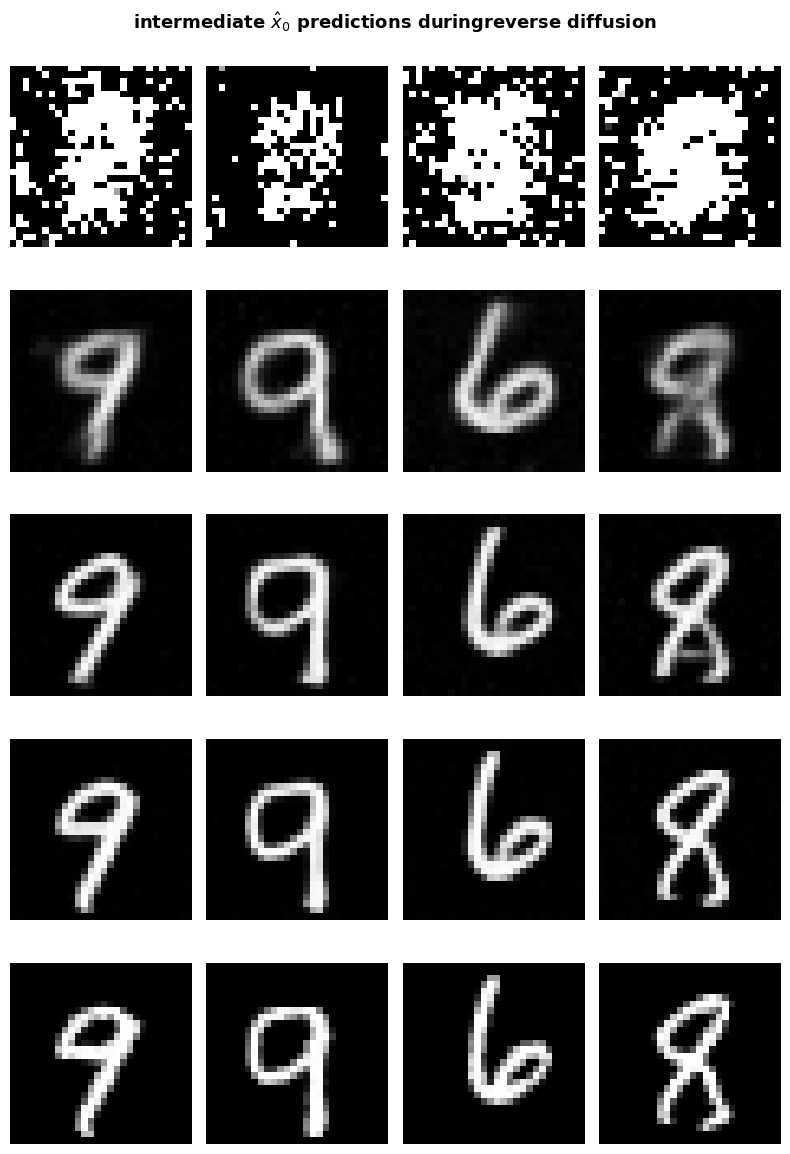

visualizationcomplete.


In [12]:
@torch.no_grad()
def p_sample(model, x_t, t_index):
    """
    TODO: One step of the reverse process.
    t_index: integer (not a batch tensor)
    Returns: x_{t-1}
    """
    model.eval()
    b = x_t.shape[0]
    t_batch = torch.full((b,), t_index, device=device, dtype=torch.long)

    eps_hat = model(x_t, t_batch)
    beta_t              = extract(betas, t_batch, x_t.shape)
    alpha_t             = extract(alphas, t_batch, x_t.shape)
    sqrt_recip_alpha_t  = torch.sqrt(1.0 / alpha_t)
    sqrt_one_minus_ahat = extract(sqrt_one_minus_alpha_hats, t_batch, x_t.shape)

    model_mean = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_ahat * eps_hat)

    if t_index > 0:
        post_var_t = extract(posterior_variance, t_batch, x_t.shape)
        noise = torch.randn_like(x_t)
        x_prev = model_mean + torch.sqrt(post_var_t) * noise
    else:
        x_prev = model_mean
    
    return x_prev


@torch.no_grad()
def p_sample_loop(model, shape):
    """
    TODO: Full reverse process from x_T to x_0.
    shape: (B, C, H, W)
    Returns: final image tensor, shape (B, C, H, W)
    """
    model.eval()
    device_ = next(model.parameters()).device
    x = torch.randn(shape, device=device_)
    
    for t_idx in tqdm(reversed(range(T)), desc='Sampling', total=T, leave=False):
        x = p_sample(model, x, t_idx)
    
    return x


def predict_x0_from_eps(x_t, t, eps):
    """
    TODO: Recover the predicted x_0 given x_t, t, and predicted noise eps.
    """
    sqrt_alpha_hat_t      = extract(sqrt_alpha_hats, t, x_t.shape)
    sqrt_one_minus_ahat_t = extract(sqrt_one_minus_alpha_hats, t, x_t.shape)
    return (x_t - sqrt_one_minus_ahat_t * eps) / sqrt_alpha_hat_t.clamp(min=1e-8)

model.load_state_dict(torch.load('/kaggle/working/ddpm_best.pt', map_location=device))
model.eval()
print("generating 64 samples")
samples = p_sample_loop(model, shape=(64, 1, 28, 28))
samples_display = (samples.clamp(-1, 1) + 1) / 2.0

grid = make_grid(samples_display, nrow=8, padding=2, pad_value=1.0)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title('DDPM Generated Samples (8×8 grid)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('generated_samples.png', dpi=100, bbox_inches='tight')
plt.show()

vis_timesteps = [T-1, int(0.75*T), int(0.5*T), int(0.25*T), 0]
x_vis = torch.randn((4, 1, 28, 28), device=device)

fig, axes = plt.subplots(len(vis_timesteps), 4, figsize=(8, 12))

@torch.no_grad()
def collect_x0_predictions(n_samples=4):
    x = torch.randn((n_samples, 1, 28, 28), device=device)
    snapshots = {}
    
    for t_idx in reversed(range(T)):
        b = x.shape[0]
        t_batch = torch.full((b,), t_idx, device=device, dtype=torch.long)
        eps_hat = model(x, t_batch)

        if t_idx in vis_timesteps:
            x0_pred = predict_x0_from_eps(x, t_batch, eps_hat)
            x0_pred = x0_pred.clamp(-1, 1)
            snapshots[t_idx] = x0_pred.cpu()
        
        x = p_sample(model, x, t_idx)
    
    return snapshots

snapshots = collect_x0_predictions(n_samples=4)

for row, ts in enumerate(vis_timesteps):
    x0_preds = snapshots.get(ts, None)
    for col in range(4):
        ax = axes[row, col]
        if x0_preds is not None:
            img = (x0_preds[col].squeeze().numpy() + 1) / 2.0  # to [0,1]
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(f't={ts}', fontsize=11, rotation=0, labelpad=40, va='center')

plt.suptitle(r'intermediate $\hat{x}_0$ predictions duringreverse diffusion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('x0_predictions.png', dpi=100, bbox_inches='tight')
plt.show()
print("visualizationcomplete.")


# TODO: Generate and display 64 samples in an 8x8 grid
# TODO: Visualize intermediate x_0 predictions during reverse diffusion


In [13]:
import shutil

import os
size = os.path.getsize('/kaggle/working/ddpm_best.pt')
print(f"Model saved: ddpm_best.pt ({size / 1e6:.1f} MB)")

Model saved: ddpm_best.pt (23.7 MB)
